In [86]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/Accidentes_Viales_20260216.csv", sep=";")

df.head()

,Fecha_Ocurrencia,Codigo_Accidente,Direccion,Barrio,Vehiculos Involucrados,Heridos,Accidente con,Muertes,Clase de Accidente
0,2024 Jan 03 12:00:00 AM,A001602262,CALLE 14A CARRERA 34 BACHUE,BACHUE,2,2,HERIDOS,0,CHOQUE
1,2024 Jan 06 12:00:00 AM,A001602263,CALLE 14 CARRERA 28 SAN JOSÃ‰,SAN JOSÃ‰,2,3,HERIDOS,0,CHOQUE
2,2024 Jan 09 12:00:00 AM,A001602264,KILOMETRO 7+800 MTS,No registra,1,1,HERIDOS,0,CHOQUE
3,2024 Jan 12 12:00:00 AM,A001602265,AVENIDA 23 N. 24 - 07 LA TIZA,LA TIZA,2,2,HERIDOS,0,CHOQUE
4,2024 Jan 12 12:00:00 AM,A001602266,KILOMETRO 3+500 MTS VIA CHICHIMENE ESTACION AC...,No registra,2,1,HERIDOS,0,CHOQUE


In [8]:
df.shape

(512, 9)

In [9]:
df.columns

Index(['Fecha_Ocurrencia', 'Codigo_Accidente', 'Direccion', 'Barrio',
       'Vehiculos Involucrados', 'Heridos', 'Accidente con', 'Muertes',
       'Clase de Accidente'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Fecha_Ocurrencia        512 non-null    object
 1   Codigo_Accidente        512 non-null    object
 2   Direccion               512 non-null    object
 3   Barrio                  512 non-null    object
 4   Vehiculos Involucrados  512 non-null    int64 
 5   Heridos                 512 non-null    int64 
 6   Accidente con           512 non-null    object
 7   Muertes                 512 non-null    object
 8   Clase de Accidente      512 non-null    object
dtypes: int64(2), object(7)
memory usage: 36.1+ KB


In [11]:
df.isnull().sum()

Fecha_Ocurrencia          0
Codigo_Accidente          0
Direccion                 0
Barrio                    0
Vehiculos Involucrados    0
Heridos                   0
Accidente con             0
Muertes                   0
Clase de Accidente        0
dtype: int64

In [15]:
df["Muertes"].value_counts()

Muertes
0    453
1     35
0     18
2      4
3      2
Name: count, dtype: int64

In [52]:
df["Muertes"]= df["Muertes"].replace("NO APLICA", 0)

In [53]:
df["Muertes"]=pd.to_numeric(df["Muertes"])

In [54]:
df["severidad"]=df["Muertes"].apply(lambda x: 1 if x > 0 else 0)

In [55]:
df["severidad"].value_counts()

severidad
0    471
1     41
Name: count, dtype: int64

In [19]:
df.columns

Index(['Fecha_Ocurrencia', 'Codigo_Accidente', 'Direccion', 'Barrio',
       'Vehiculos Involucrados', 'Heridos', 'Accidente con', 'Muertes',
       'Clase de Accidente', 'severidad'],
      dtype='object')

In [56]:
df = df.drop_duplicates()

In [57]:
df.shape

(512, 14)

In [58]:
df.isnull().sum()

Fecha_Ocurrencia          0
Codigo_Accidente          0
Direccion                 0
Barrio                    0
Vehiculos Involucrados    0
Heridos                   0
Accidente con             0
Muertes                   0
Clase de Accidente        0
hora                      0
dia_semana                0
mes                       0
fin_semana                0
severidad                 0
dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Fecha_Ocurrencia        512 non-null    object
 1   Codigo_Accidente        512 non-null    object
 2   Direccion               512 non-null    object
 3   Barrio                  512 non-null    object
 4   Vehiculos Involucrados  512 non-null    int64 
 5   Heridos                 512 non-null    int64 
 6   Accidente con           512 non-null    object
 7   Muertes                 512 non-null    object
 8   Clase de Accidente      512 non-null    object
dtypes: int64(2), object(7)
memory usage: 36.1+ KB


In [59]:
df["Fecha_Ocurrencia"] = pd.to_datetime(df["Fecha_Ocurrencia"])

In [60]:
df["hora"] = df["Fecha_Ocurrencia"].dt.hour

In [61]:
df["dia_semana"] = df["Fecha_Ocurrencia"].dt.day_name()

In [63]:
df["mes"] = df["Fecha_Ocurrencia"].dt.month

In [64]:
df["fin_semana"] = df["dia_semana"].isin(["Saturday","Sunday"]).astype(int)

In [65]:
df["Barrio"].value_counts().head(10)

Barrio
No registra                    115
SIN INFORMACIÃ“N DEL BARRIO     86
VÃA GRANADA-VILLAVICENCIO      50
BACHUE                          27
MANCERA                         24
COOPERATIVO                     22
CENTRO                          21
SAN JOSÃ‰                       15
SAN CRISTOBAL                   13
INDEPENDENCIA                   12
Name: count, dtype: int64

In [66]:
features = [
    "Vehiculos Involucrados",
    "Heridos",
    "hora",
    "mes",
    "fin_semana",
    "Accidente con",
    "Clase de Accidente"
]

X = df[features]

y = df["severidad"]

In [67]:
X = pd.get_dummies(X, drop_first=True)

In [68]:
print(X.shape)
print(y.shape)

(512, 10)
(512,)


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [70]:
model = RandomForestClassifier(
    n_estimators = 2000,
    random_state = 42
)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=2000, random_state=42)

In [71]:
pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        93
           1       1.00      1.00      1.00        10

    accuracy                           1.00       103
   macro avg       1.00      1.00      1.00       103
weighted avg       1.00      1.00      1.00       103



In [72]:
confusion_matrix(y_test, pred)

array([[93,  0],
       [ 0, 10]], dtype=int64)

In [73]:
df.groupby("Heridos")["severidad"].mean()

Heridos
0    0.296703
1    0.038462
2    0.028777
3    0.023810
4    0.000000
5    0.000000
Name: severidad, dtype: float64

In [74]:
model.feature_importances_

array([0.03403692, 0.05084167, 0.        , 0.05304991, 0.00513405,
       0.1600464 , 0.68747723, 0.00581956, 0.00274856, 0.00084569])

In [75]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

Accidente con_MUERTOS             0.687477
Accidente con_HERIDOS             0.160046
mes                               0.053050
Heridos                           0.050842
Vehiculos Involucrados            0.034037
Clase de Accidente_CHOQUE         0.005820
fin_semana                        0.005134
Clase de Accidente_OTRO           0.002749
Clase de Accidente_VOLCAMIENTO    0.000846
hora                              0.000000
dtype: float64

El modelo solo esta aprendiendo severidad, entonces se cambiara el Features para hacerlo mas real.

In [76]:
features = [
    "Vehiculos Involucrados",
    "hora",
    "mes",
    "fin_semana",
    "Clase de Accidente"
]

In [77]:
X = df[features]
y = df["severidad"]

X = pd.get_dummies(X, drop_first=True)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [79]:
model = RandomForestClassifier(
    n_estimators=2000,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))
confusion_matrix(y_test, pred)

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        93
           1       0.00      0.00      0.00        10

    accuracy                           0.90       103
   macro avg       0.45      0.50      0.47       103
weighted avg       0.82      0.90      0.86       103



c:\Users\caror\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caror\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caror\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[93,  0],
       [10,  0]], dtype=int64)

Se aplica SMOTE (sinthetic Minority Over-Sampling Technique)

In [81]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [82]:
y_train.value_counts()

severidad
0    378
1     31
Name: count, dtype: int64

In [83]:
y_train_bal.value_counts()

severidad
0    378
1    378
Name: count, dtype: int64

In [84]:
model = RandomForestClassifier(
    n_estimators=2000,
    random_state=42
)

model.fit(X_train_bal, y_train_bal)

RandomForestClassifier(n_estimators=2000, random_state=42)

In [85]:
pred = model.predict(X_test)

print(classification_report(y_test, pred))
confusion_matrix(y_test, pred)

              precision    recall  f1-score   support

           0       0.95      0.77      0.85        93
           1       0.22      0.60      0.32        10

    accuracy                           0.76       103
   macro avg       0.58      0.69      0.59       103
weighted avg       0.88      0.76      0.80       103



array([[72, 21],
       [ 4,  6]], dtype=int64)

In [87]:
importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values(ascending=False)

Vehiculos Involucrados            0.500229
mes                               0.329001
fin_semana                        0.094684
Clase de Accidente_CHOQUE         0.063052
Clase de Accidente_OTRO           0.011476
Clase de Accidente_VOLCAMIENTO    0.001558
hora                              0.000000
dtype: float64

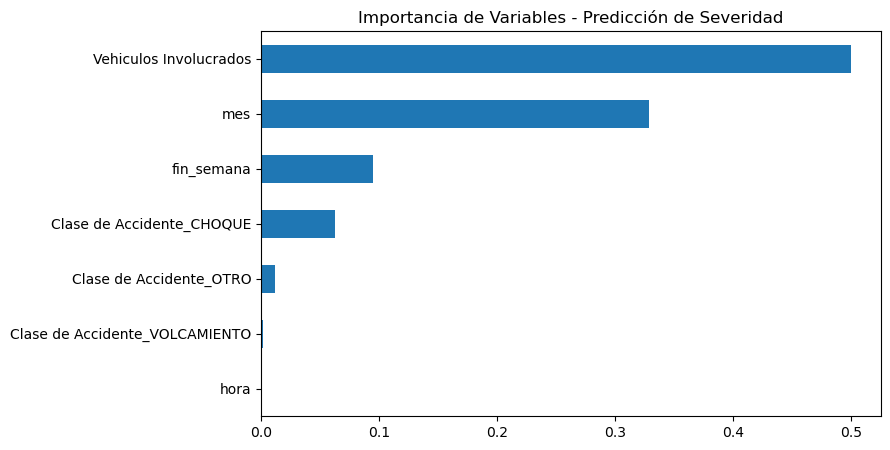

In [88]:
importances.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Importancia de Variables - Predicción de Severidad")
plt.show()